
<h1 id="数据清洗之数据预处理">数据清洗之数据预处理作业<a class="anchor-link" href="#数据清洗之数据预处理">¶</a></h1>


# 每行注释下，完成对应代码（写作对应的cell中），并运行检查

In [62]:
#导入相应模块
import pandas as pd
import os

In [63]:
#查询当前目录
os.getcwd()

'D:\\code\\python\\BigDataAnalyze'

In [64]:
#设置当前数据所在目录为实验数据文件夹
os.chdir('D:/code/python/BigDataAnalyze')

In [65]:
#读取MotorcycleData.csv数据，转为panda格式
df = pd.read_csv('MotorcycleData.csv', encoding='gbk')


<h2 id="1.-重复值处理">1. 重复值处理<a class="anchor-link" href="#1.-重复值处理">¶</a></h2>


In [66]:
# 显示前五行
df.head()

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
0,Used,mint!!! very low miles,"$11,412","McHenry, Illinois, United States",2013.0,"16,000",Black,Harley-Davidson,Unspecified,Touring,...,NaN,FALSE,8.1,NaN,2427,Private Seller,Clear,True,FALSE,28.0
1,Used,Perfect condition,"$17,200","Fort Recovery, Ohio, United States",2016.0,60,Black,Harley-Davidson,Vehicle has an existing warranty,Touring,...,NaN,FALSE,100,17,657,Private Seller,Clear,True,TRUE,0.0
2,Used,NaN,"$3,872","Chicago, Illinois, United States",1970.0,"25,763",Silver/Blue,BMW,Vehicle does NOT have an existing warranty,R-Series,...,NaN,FALSE,100,NaN,136,NaN,Clear,True,FALSE,26.0
3,Used,CLEAN TITLE READY TO RIDE HOME,"$6,575","Green Bay, Wisconsin, United States",2009.0,"33,142",Red,Harley-Davidson,NaN,Touring,...,NaN,FALSE,100,NaN,2920,Dealer,Clear,True,FALSE,11.0
4,Used,NaN,"$10,000","West Bend, Wisconsin, United States",2012.0,"17,800",Blue,Harley-Davidson,NO WARRANTY,Touring,...,NaN,FALSE,100,13,271,OWNER,Clear,True,TRUE,0.0



<ul>
<li>对价格和里程数数据进行处理</li>
</ul>


In [67]:
# 自定义一个函数，将价格中的$删除，并且去除数字中的逗号
def clean_currency(x):
    if isinstance(x, str):
        return x.replace('$', '').replace(',', '')
    return x

In [68]:
# 调用上述函数对Price和Mileage字段的数据进行操作
df['Price'] = df['Price'].apply(clean_currency).astype(float)
df['Mileage'] = pd.to_numeric(df['Mileage'].apply(clean_currency), errors='coerce')

In [69]:
# 判断数据集是否存在重复，输出判断结果（True or False）
df.duplicated().any()

np.True_

In [70]:
#查看哪些数据重复
df[df.duplicated()]

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
57,Used,NaN,4050.0,"Gilberts, Illinois, United States",2006.0,6650.0,Black,Harley-Davidson,Vehicle does NOT have an existing warranty,Softail,...,NaN,FALSE,NaN,7<,58,Private Seller,Clear,True,TRUE,3.0
63,Used,NaN,7300.0,"Rolling Meadows, Illinois, United States",1997.0,20000.0,Black,Harley-Davidson,Vehicle does NOT have an existing warranty,Sportster,...,NaN,TRUE,100,5<,111,Private Seller,Clear,False,TRUE,NaN
64,Used,Dent and scratch free. Paint and chrome in exc...,5000.0,"South Bend, Indiana, United States",2003.0,1350.0,Black,Harley-Davidson,Vehicle does NOT have an existing warranty,Sportster,...,NaN,FALSE,100,14,37,Private Seller,Clear,False,TRUE,NaN
67,Used,NaN,3250.0,"Valparaiso, Indiana, United States",2003.0,22896.0,Blue/Green Metallic,Harley-Davidson,Vehicle does NOT have an existing warranty,Sportster,...,NaN,FALSE,100,9<,109,Private Seller,Clear,True,TRUE,11.0
103,Used,NaN,10995.0,"Delafield, Wisconsin, United States",2002.0,4185.0,Blue,Harley-Davidson,Vehicle does NOT have an existing warranty,Other,...,NaN,FALSE,100,NaN,91,Private Seller,Clear,False,TRUE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7319,New,NaN,11695.0,"Plano, Texas, United States",2017.0,7.0,Red,Ducati,Unspecified,Monster 821 Red,...,NaN,FALSE,100,NaN,161,Dealer,Clear,False,FALSE,NaN
7384,New,NaN,26999.0,"Greensboro, North Carolina, United States",2017.0,3.0,Black,Indian,Unspecified,Roadmaster?,...,TRUE,100,NaN,312,Dealer,Clear,FALSE,False,NaN,NaN
7389,New,NaN,18999.0,"Greensboro, North Carolina, United States",2017.0,3.0,Green,Indian,Unspecified,Chief?Vintage,...,NaN,TRUE,100,NaN,312,Dealer,Clear,False,FALSE,NaN
7402,Used,NaN,5200.0,"Raymond, New Hampshire, United States",2013.0,5307.0,Black,Suzuki,NaN,GSX-R750,...,NaN,TRUE,4.7,NaN,12409,Dealer,Salvage,False,FALSE,NaN


In [71]:
 #统计重复的数量（行记录）
df.duplicated().sum()

np.int64(1221)

In [72]:
#删除所有变量都重复的行, 注意不加inplace = True，观察结果
df.drop_duplicates()

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
0,Used,mint!!! very low miles,11412.0,"McHenry, Illinois, United States",2013.0,16000.0,Black,Harley-Davidson,Unspecified,Touring,...,NaN,FALSE,8.1,NaN,2427,Private Seller,Clear,True,FALSE,28.0
1,Used,Perfect condition,17200.0,"Fort Recovery, Ohio, United States",2016.0,60.0,Black,Harley-Davidson,Vehicle has an existing warranty,Touring,...,NaN,FALSE,100,17,657,Private Seller,Clear,True,TRUE,0.0
2,Used,NaN,3872.0,"Chicago, Illinois, United States",1970.0,25763.0,Silver/Blue,BMW,Vehicle does NOT have an existing warranty,R-Series,...,NaN,FALSE,100,NaN,136,NaN,Clear,True,FALSE,26.0
3,Used,CLEAN TITLE READY TO RIDE HOME,6575.0,"Green Bay, Wisconsin, United States",2009.0,33142.0,Red,Harley-Davidson,NaN,Touring,...,NaN,FALSE,100,NaN,2920,Dealer,Clear,True,FALSE,11.0
4,Used,NaN,10000.0,"West Bend, Wisconsin, United States",2012.0,17800.0,Blue,Harley-Davidson,NO WARRANTY,Touring,...,NaN,FALSE,100,13,271,OWNER,Clear,True,TRUE,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7488,Used,NaN,3900.0,"Raymond, New Hampshire, United States",2004.0,23681.0,Black,Harley-Davidson,NaN,FXDI,...,NaN,TRUE,4.7,NaN,12409,Dealer,Salvage,False,FALSE,NaN
7489,Used,NaN,8900.0,"Raymond, New Hampshire, United States",2013.0,5821.0,Black,Suzuki,NaN,GSX1300RA,...,NaN,TRUE,4.7,NaN,12409,Dealer,Salvage,False,FALSE,NaN
7490,Used,NaN,7800.0,"Raymond, New Hampshire, United States",2011.0,48616.0,Red,BMW,NaN,R1200GS,...,NaN,TRUE,4.7,NaN,12409,Dealer,Salvage,False,FALSE,NaN
7491,Used,NaN,7900.0,"Raymond, New Hampshire, United States",2014.0,6185.0,TWO TONE,Yamaha,NaN,YZF-R1,...,NaN,TRUE,4.7,NaN,12409,Dealer,Salvage,False,FALSE,NaN


In [73]:
#对'Condition','Condition_Desc','Price','Location'四个属性重复情况去重，inplace设置为真
df.drop_duplicates(subset=['Condition','Condition_Desc','Price','Location'], inplace=True)

In [74]:
#查看数据集基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5356 entries, 0 to 7486
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Condition       5356 non-null   object 
 1   Condition_Desc  1324 non-null   object 
 2   Price           5356 non-null   float64
 3   Location        5354 non-null   object 
 4   Model_Year      5352 non-null   float64
 5   Mileage         5331 non-null   float64
 6   Exterior_Color  4805 non-null   object 
 7   Make            5352 non-null   object 
 8   Warranty        3695 non-null   object 
 9   Model           5278 non-null   object 
 10  Sub_Model       1835 non-null   object 
 11  Type            4250 non-null   object 
 12  Vehicle_Title   150 non-null    object 
 13  OBO             5312 non-null   object 
 14  Feedback_Perc   4729 non-null   object 
 15  Watch_Count     2676 non-null   object 
 16  N_Reviews       5351 non-null   object 
 17  Seller_Status   4864 non-null   object


<h2 id="2.-缺失值处理">2. 缺失值处理<a class="anchor-link" href="#2.-缺失值处理">¶</a></h2>


In [75]:
#求缺失比例
df.isnull().mean()

Condition         0.000000
Condition_Desc    0.752801
Price             0.000000
Location          0.000373
Model_Year        0.000747
Mileage           0.004668
Exterior_Color    0.102875
Make              0.000747
Warranty          0.310119
Model             0.014563
Sub_Model         0.657394
Type              0.206497
Vehicle_Title     0.971994
OBO               0.008215
Feedback_Perc     0.117065
Watch_Count       0.500373
N_Reviews         0.000934
Seller_Status     0.091860
Vehicle_Tile      0.009522
Auction           0.002054
Buy_Now           0.024645
Bid_Count         0.690814
dtype: float64

删除法

In [76]:
#直接删除法
df.dropna()

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count


In [77]:
#只要有缺失，就删除这一列（采用axis参数）
df.dropna(axis=1)

,Condition,Price
0,Used,11412.0
1,Used,17200.0
2,Used,3872.0
3,Used,6575.0
4,Used,10000.0
...,...,...
7478,Used,9900.0
7479,Used,2900.0
7482,Used,7200.0
7484,Used,5000.0


In [78]:
#只要有缺失，就删除这一行（采用axis参数），等价于df.dropna()
df.dropna(axis=0)

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count



<ul>
<li>axis = 0 或者 1代表的函数在数据集作用的方向，0代表沿着行的方向，1代表沿着列的方向</li>
</ul>


In [79]:
 # 基于三个属性Condition','Price','Mileage'的缺失情况来删除对应的行
df.dropna(subset=['Condition', 'Price', 'Mileage'], inplace=True)

替换法

In [80]:
#显示前10行
df.head(10)

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
0,Used,mint!!! very low miles,11412.0,"McHenry, Illinois, United States",2013.0,16000.0,Black,Harley-Davidson,Unspecified,Touring,...,NaN,FALSE,8.1,NaN,2427,Private Seller,Clear,True,FALSE,28.0
1,Used,Perfect condition,17200.0,"Fort Recovery, Ohio, United States",2016.0,60.0,Black,Harley-Davidson,Vehicle has an existing warranty,Touring,...,NaN,FALSE,100,17,657,Private Seller,Clear,True,TRUE,0.0
2,Used,NaN,3872.0,"Chicago, Illinois, United States",1970.0,25763.0,Silver/Blue,BMW,Vehicle does NOT have an existing warranty,R-Series,...,NaN,FALSE,100,NaN,136,NaN,Clear,True,FALSE,26.0
3,Used,CLEAN TITLE READY TO RIDE HOME,6575.0,"Green Bay, Wisconsin, United States",2009.0,33142.0,Red,Harley-Davidson,NaN,Touring,...,NaN,FALSE,100,NaN,2920,Dealer,Clear,True,FALSE,11.0
4,Used,NaN,10000.0,"West Bend, Wisconsin, United States",2012.0,17800.0,Blue,Harley-Davidson,NO WARRANTY,Touring,...,NaN,FALSE,100,13,271,OWNER,Clear,True,TRUE,0.0
5,Used,It&#039;s a &#039;72 in good shape,1500.0,"Watervliet, Michigan, United States",1972.0,0.0,Red,Harley-Davidson,Vehicle does NOT have an existing warranty,Sportster,...,NaN,FALSE,100,NaN,412,Private Seller,Clear,True,FALSE,1.0
6,Used,NaN,24900.0,"Sterling, Illinois, United States",2010.0,5548.0,Grey / Red / Silver Metallic,Harley-Davidson,NaN,Touring,...,NaN,FALSE,9.8,NaN,6229,Dealer,Clear,True,FALSE,1.0
7,Used,NaN,1400.0,"Williamston, Michigan, United States",1975.0,17868.0,Black,Harley-Davidson,Vehicle does NOT have an existing warranty,Sportster,...,NaN,FALSE,9.7,NaN,1159,Private Seller,Clear,True,FALSE,6.0
8,Used,NaN,5100.0,"Palatine, Illinois, United States",2014.0,2800.0,Cherry Red,Harley-Davidson,Vehicle does NOT have an existing warranty,Touring,...,NaN,FALSE,NaN,16,3,Private Seller,Clear,True,TRUE,6.0
9,Used,NaN,8000.0,"Chicago, Illinois, United States",2015.0,3000.0,Black,Harley-Davidson,Vehicle has an existing warranty,Sportster,...,NaN,FALSE,NaN,NaN,1,Private Seller,Clear,True,FALSE,0.0


In [81]:
# Mileage字段用均值填补
df['Mileage'].fillna(df['Mileage'].mean())

0       16000.0
1          60.0
2       25763.0
3       33142.0
4       17800.0
         ...   
7478    20851.0
7479     2905.0
7482    29201.0
7484    12583.0
7486     9305.0
Name: Mileage, Length: 5331, dtype: float64

In [82]:
#Mileage字段中位数填补
df['Mileage'].fillna(df['Mileage'].median())

0       16000.0
1          60.0
2       25763.0
3       33142.0
4       17800.0
         ...   
7478    20851.0
7479     2905.0
7482    29201.0
7484    12583.0
7486     9305.0
Name: Mileage, Length: 5331, dtype: float64

In [83]:
#查看Exterior_Color字段为空有哪些数据集
df[df['Exterior_Color'].isnull()]

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
14,Used,NaN,5500.0,"Davenport, Iowa, United States",2008.0,22102.0,NaN,Harley-Davidson,Vehicle does NOT have an existing warranty,Touring,...,NaN,FALSE,9.3,NaN,244,Private Seller,Clear,True,FALSE,16.0
35,Used,NaN,7700.0,"Roselle, Illinois, United States",2007.0,10893.0,NaN,Harley-Davidson,NaN,Other,...,NaN,FALSE,100,NaN,236,NaN,Clear,False,TRUE,NaN
41,Used,NaN,6800.0,"Hampshire, Illinois, United States",2003.0,55782.0,NaN,Harley-Davidson,Vehicle does NOT have an existing warranty,Softail,...,NaN,TRUE,100,2<,298,Private Seller,Clear,False,TRUE,NaN
55,Used,NaN,29500.0,"Parma, Michigan, United States",1950.0,8471.0,NaN,Harley-Davidson,NaN,Other,...,NaN,TRUE,100,24,216,NaN,Clear,False,TRUE,NaN
72,Used,NaN,6500.0,"Bourbonnais, Illinois, United States",1986.0,55300.0,NaN,Harley-Davidson,NaN,Touring,...,NaN,TRUE,100,2<,1,Private Seller,Clear,False,TRUE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6934,Used,NaN,11500.0,"Pori, default, Finland",2014.0,190000.0,NaN,Other Makes,NaN,316i,...,NaN,FALSE,NaN,NaN,0,Private Seller,"Rebuilt, Rebuildable &amp; Reconstructed",False,TRUE,NaN
7237,Used,NaN,3900.0,"London, Kentucky, United States",2007.0,9829.0,NaN,Hyosung,NaN,Aquila,...,NaN,TRUE,3.3,NaN,309,Dealer,Clear,False,FALSE,NaN
7320,Used,NaN,300.0,"Charlottetown, Prince Edward Island, Canada",2013.0,111111.0,NaN,Victory,NaN,NaN,...,NaN,TRUE,NaN,8<,0,NaN,NaN,False,TRUE,NaN
7321,Used,NaN,250.0,"Charlottetown, Prince Edward Island, Canada",2013.0,111111.0,NaN,Victory,NaN,NaN,...,NaN,TRUE,NaN,2<,0,NaN,NaN,False,TRUE,NaN


In [84]:
# Exterior_Color众数填补
df['Exterior_Color'].fillna(df['Exterior_Color'].mode()[0], inplace=True)

C:\Users\MouKexin\AppData\Local\Temp\ipykernel_13592\2465213321.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Exterior_Color'].fillna(df['Exterior_Color'].mode()[0], inplace=True)


In [85]:
# 所有缺失用20填补
df.fillna(20)

,Condition,Condition_Desc,Price,Location,Model_Year,Mileage,Exterior_Color,Make,Warranty,Model,...,Vehicle_Title,OBO,Feedback_Perc,Watch_Count,N_Reviews,Seller_Status,Vehicle_Tile,Auction,Buy_Now,Bid_Count
0,Used,mint!!! very low miles,11412.0,"McHenry, Illinois, United States",2013.0,16000.0,Black,Harley-Davidson,Unspecified,Touring,...,20,FALSE,8.1,20,2427,Private Seller,Clear,True,FALSE,28.0
1,Used,Perfect condition,17200.0,"Fort Recovery, Ohio, United States",2016.0,60.0,Black,Harley-Davidson,Vehicle has an existing warranty,Touring,...,20,FALSE,100,17,657,Private Seller,Clear,True,TRUE,0.0
2,Used,20,3872.0,"Chicago, Illinois, United States",1970.0,25763.0,Silver/Blue,BMW,Vehicle does NOT have an existing warranty,R-Series,...,20,FALSE,100,20,136,20,Clear,True,FALSE,26.0
3,Used,CLEAN TITLE READY TO RIDE HOME,6575.0,"Green Bay, Wisconsin, United States",2009.0,33142.0,Red,Harley-Davidson,20,Touring,...,20,FALSE,100,20,2920,Dealer,Clear,True,FALSE,11.0
4,Used,20,10000.0,"West Bend, Wisconsin, United States",2012.0,17800.0,Blue,Harley-Davidson,NO WARRANTY,Touring,...,20,FALSE,100,13,271,OWNER,Clear,True,TRUE,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7478,Used,20,9900.0,"Raymond, New Hampshire, United States",2011.0,20851.0,Brown,Harley-Davidson,20,FLTRU,...,20,TRUE,4.7,20,12409,Dealer,Salvage,False,FALSE,20.0
7479,Used,20,2900.0,"Raymond, New Hampshire, United States",2013.0,2905.0,Black,Suzuki,20,SV,...,20,TRUE,4.7,20,12409,Dealer,Salvage,False,FALSE,20.0
7482,Used,20,7200.0,"Raymond, New Hampshire, United States",2006.0,29201.0,Black,Harley-Davidson,20,FLTRI,...,20,TRUE,4.7,20,12409,Dealer,Salvage,False,FALSE,20.0
7484,Used,20,5000.0,"Raymond, New Hampshire, United States",2004.0,12583.0,Black,Harley-Davidson,20,FXDI,...,20,TRUE,4.7,20,12409,Dealer,Salvage,False,FALSE,20.0


In [86]:
# Exterior_Color使用众数,Mileage使用均值，一句代码
df.fillna({'Exterior_Color': df['Exterior_Color'].mode()[0], 'Mileage': df['Mileage'].mean()}, inplace=True)

In [87]:
#Exterior_Color前向填补
df['Exterior_Color'].fillna(method='ffill')

C:\Users\MouKexin\AppData\Local\Temp\ipykernel_13592\1960289540.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Exterior_Color'].fillna(method='ffill')


0             Black
1             Black
2       Silver/Blue
3               Red
4              Blue
           ...     
7478          Brown
7479          Black
7482          Black
7484          Black
7486          Black
Name: Exterior_Color, Length: 5331, dtype: object

In [88]:
#Exterior_Color后向填补
df['Exterior_Color'].fillna(method='bfill')

C:\Users\MouKexin\AppData\Local\Temp\ipykernel_13592\3272868267.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Exterior_Color'].fillna(method='bfill')


0             Black
1             Black
2       Silver/Blue
3               Red
4              Blue
           ...     
7478          Brown
7479          Black
7482          Black
7484          Black
7486          Black
Name: Exterior_Color, Length: 5331, dtype: object


<h2 id="3.异常值处理">3.异常值处理<a class="anchor-link" href="#3.异常值处理">¶</a></h2>



<ul>
<li>异常值检测可以使用均值的2倍标准差范围，也可以使用上下4分位数差方法</li>
</ul>


In [89]:
# price异常值检测,标准差法，系数2.5,输出标准差法异常值上限检测和标准差法异常值下限检测
up = df['Price'].mean() + 2.5 * df['Price'].std()
down = df['Price'].mean() - 2.5 * df['Price'].std()
print(up, down)

31690.24880164732 -11579.974556665142


In [90]:
# 异常值检测之箱线图法，输出箱线图法异常值上限检测值和箱线图法异常值下限检测值
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1
up_box = q3 + 1.5 * iqr
down_box = q1 - 1.5 * iqr
print(up_box, down_box)

27747.5 -10248.5


In [91]:
# 对价格进行描述性统计
df['Price'].describe()

count      5331.000000
mean      10055.137122
std        8654.044672
min           0.000000
25%        4000.000000
50%        7900.000000
75%       13499.000000
max      100000.000000
Name: Price, dtype: float64

<Axes: >

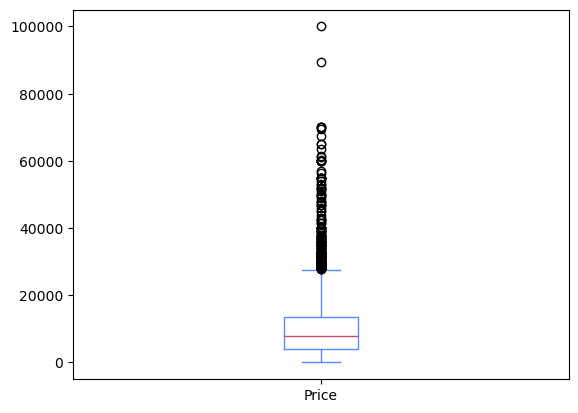

In [92]:
#绘制箱图
df['Price'].plot(kind='box')

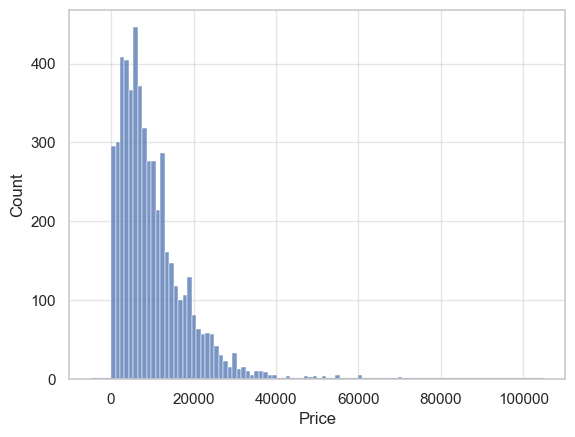

In [93]:
# 导入绘图模块
import matplotlib.pyplot as plt
import seaborn as sns
# 设置绘图风格
sns.set(style="whitegrid")
# 绘制直方图
sns.histplot(df['Price'], kde=False)
# 绘制核密度图
sns.kdeplot(df['Price'])
# 图形展现
plt.show()

In [94]:
# 用99分位数和1分位数替换
#计算P1和P99
p1 = df['Price'].quantile(0.01)
p99 = df['Price'].quantile(0.99)

In [95]:
#先创建一个新变量price_new，进行赋值，然后将满足条件的数据进行替换
df['Price_new'] = df['Price']
df.loc[df['Price_new'] > p99, 'Price_new'] = p99
df.loc[df['Price_new'] < p1, 'Price_new'] = p1

In [96]:
# describe对price新旧两列进行显示
df[['Price', 'Price_new']].describe()

,Price,Price_new
count,5331.000000,5331.000000
mean,10055.137122,9904.708685
std,8654.044672,7890.781283
min,0.000000,102.000000
25%,4000.000000,4000.000000
50%,7900.000000,7900.000000
75%,13499.000000,13499.000000
max,100000.000000,40000.000000


<Axes: >

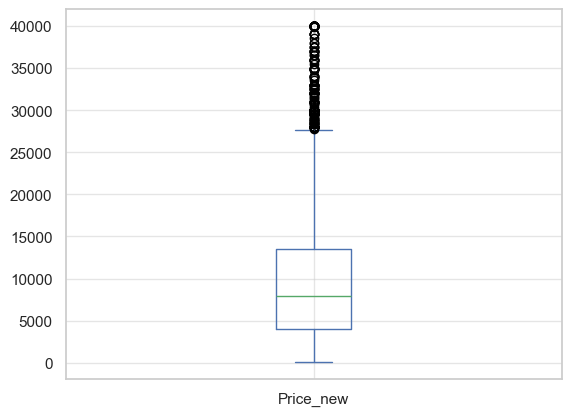

In [97]:
#对Price_new绘制箱图
df['Price_new'].plot(kind='box')